In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from ipywidgets import interact, FloatSlider, IntSlider

In [3]:
def calculate_w_rms(w_s, w_g, h_start, h_end):
    """
    w_g: ground wind speed =2,1
    w_s: beam slew rate =0
    """

    inside_integral= lambda h: (w_s * h + w_g + 30.0 * np.exp(-((h - 9400.0) / 4800.0)**2))**2
    
    intervall = h_end - h_start  
    
    integral_val = quad(inside_integral, h_start, h_end)[0]
   
    w = np.sqrt((1.0 / intervall) * integral_val)
    return w

def hufnagel_valley_profile(h, w, A): #C_n^2
    """
    A: ground level value of C_n^2(0)
    """
    term1 = 0.00594 * (w / 27.0)**2 * (1e-5 * h)**10 * np.exp(-h / 1000.0)
    term2 = 2.7e-16 * np.exp(-h / 1500.0)
    term3 = A * np.exp(-h / 100.0)
    return term1 + term2 + term3



w_effektiv = calculate_w_rms(0, 2.1, 5000, 20000) 
altitudes = np.linspace(0, 500*1e3, 1000)

turbolenz = hufnagel_valley_profile(altitudes, w_effektiv, 1.7e-14)#C_n^2
print(turbolenz)


[1.72700000e-014 3.07372145e-016 1.39294270e-016 9.92336365e-017
 7.10810902e-017 5.09382522e-017 3.65682197e-017 2.64067485e-017
 1.93681902e-017 1.46968991e-017 1.18509099e-017 1.04158217e-017
 1.00477260e-017 1.04418962e-017 1.13214173e-017 1.24385736e-017
 1.35820525e-017 1.45845042e-017 1.53270444e-017 1.57392858e-017
 1.57950321e-017 1.55047177e-017 1.49060600e-017 1.40543547e-017
 1.30135473e-017 1.18488226e-017 1.06210565e-017 9.38316158e-018
 8.17813134e-018 7.03846414e-018 5.98660324e-018 5.03604118e-018
 4.19278563e-018 3.45694847e-018 2.82428765e-018 2.28759278e-018
 1.83785619e-018 1.46520973e-018 1.15963374e-018 9.11461632e-019
 7.11711339e-019 5.52277902e-019 4.26020040e-019 3.26769971e-019
 2.49291151e-019 1.89203645e-019 1.42892172e-019 1.07407784e-019
 8.03706956e-020 5.98791066e-020 4.44267534e-020 3.28304687e-020
 2.41679732e-020 1.77254627e-020 1.29541562e-020 9.43477578e-021
 6.84886470e-021 4.95588180e-021 3.57508848e-021 2.57135382e-021
 1.84412121e-021 1.318897

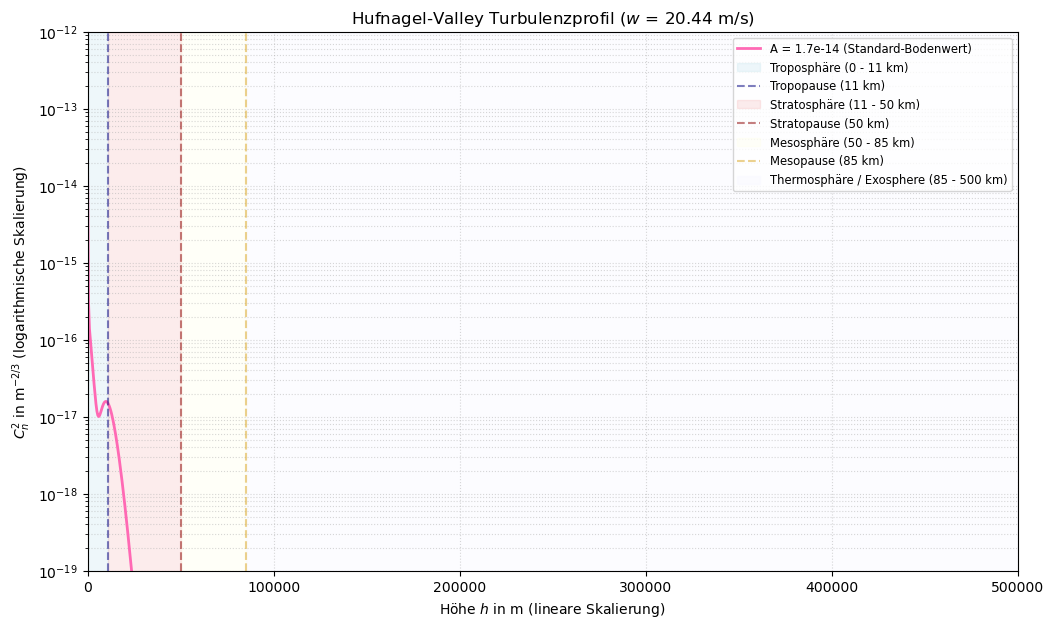

In [4]:
plt.figure(figsize=(12, 7))

# semilogy: Die Höhe auf der X-Achse läuft linear von 0 bis 500 km.
# C_n^2 auf der Y-Achse ist logarithmisch skaliert (weil es um Dimensionen fällt).
plt.semilogy(altitudes, turbolenz, label=f"A = 1.7e-14 (Standard-Bodenwert)", color='hotpink', linewidth=2)

# Maßstabsgetreue atmosphärische Zonen einzeichnen (0 bis 500 km)
plt.axvspan(0, 11000, color='lightblue', alpha=0.2, label='Troposphäre (0 - 11 km)')
plt.axvline(11000, color='navy', linestyle='--', alpha=0.5, label='Tropopause (11 km)')

plt.axvspan(11000, 50000, color='lightcoral', alpha=0.15, label='Stratosphäre (11 - 50 km)')
plt.axvline(50000, color='darkred', linestyle='--', alpha=0.5, label='Stratopause (50 km)')

plt.axvspan(50000, 85000, color='lightyellow', alpha=0.2, label='Mesosphäre (50 - 85 km)')
plt.axvline(85000, color='goldenrod', linestyle='--', alpha=0.5, label='Mesopause (85 km)')

plt.axvspan(85000, 500000, color='ghostwhite', alpha=0.4, label='Thermosphäre / Exosphere (85 - 500 km)')




# Beschriftungen
plt.xlabel("Höhe $h$ in m (lineare Skalierung)")
plt.ylabel("$C_n^2$ in $\\text{m}^{-2/3}$ (logarithmische Skalierung)")
plt.title(f"Hufnagel-Valley Turbulenzprofil ($w$ = {w_effektiv:.2f} m/s)")

plt.xlim(0, 500000)
plt.ylim(1e-19, 1e-12)

plt.grid(True, which="both", ls=":", alpha=0.5)
plt.legend(loc="upper right", fontsize='small')
plt.show()

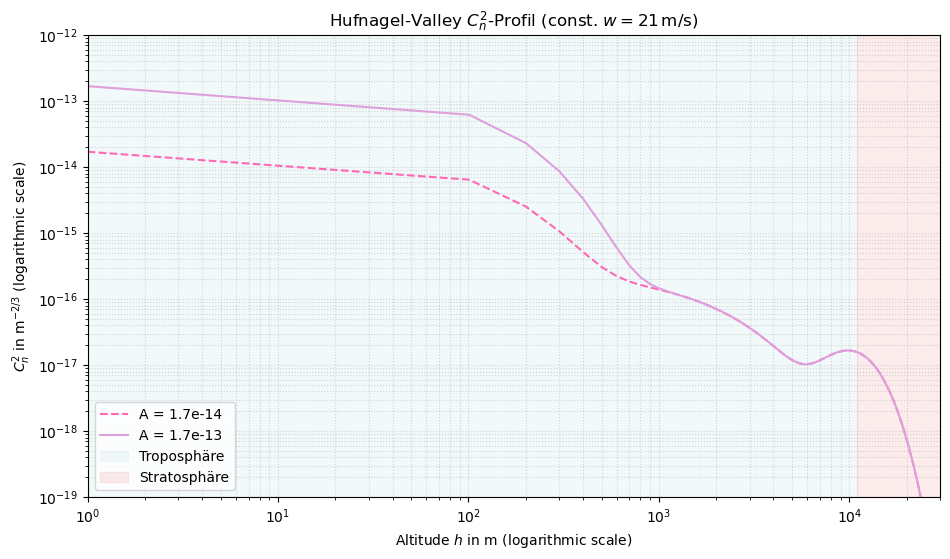

In [5]:
#plot altitude 0-500km leo

w_rms = 21.0 #assumption constant
A_ground_1 = 1.7e-14   # Standard-Normalwert
A_ground_2 = 1.7e-13   # Starker Bodenturbulenz-Wert (z.B. Stadtumgebung)


altitude = np.arange(1, 500001, 100)

cn2_profile_1 = hufnagel_valley_profile(altitude, w_rms, A_ground_1)
cn2_profile_2 = hufnagel_valley_profile(altitude, w_rms, A_ground_2)


# --- DOPPELLOGARITHMISCHER PLOT (LOG-LOG) ---
plt.figure(figsize=(11, 6))


plt.loglog(altitude, cn2_profile_1, label=f"A = {A_ground_1:.1e}", color='hotpink', linestyle='--')
plt.loglog(altitude, cn2_profile_2, label=f"A = {A_ground_2:.1e}", color='plum')


plt.axvspan(1, 11000, color='lightblue', alpha=0.15, label='Troposphäre')
plt.axvspan(11000, 30000, color='lightcoral', alpha=0.15, label='Stratosphäre')


plt.xlabel("Altitude $h$ in m (logarithmic scale)")
plt.ylabel("$C_n^2$ in $\\text{m}^{-2/3}$ (logarithmic scale)")
plt.title("Hufnagel-Valley $C_n^2$-Profil (const. $w=21\\,\\text{m/s}$)")

plt.xlim(1, 30000)
plt.ylim(1e-19, 1e-12)

plt.grid(True, which="both", ls=":", alpha=0.5)
plt.legend(loc="lower left") 
plt.show()



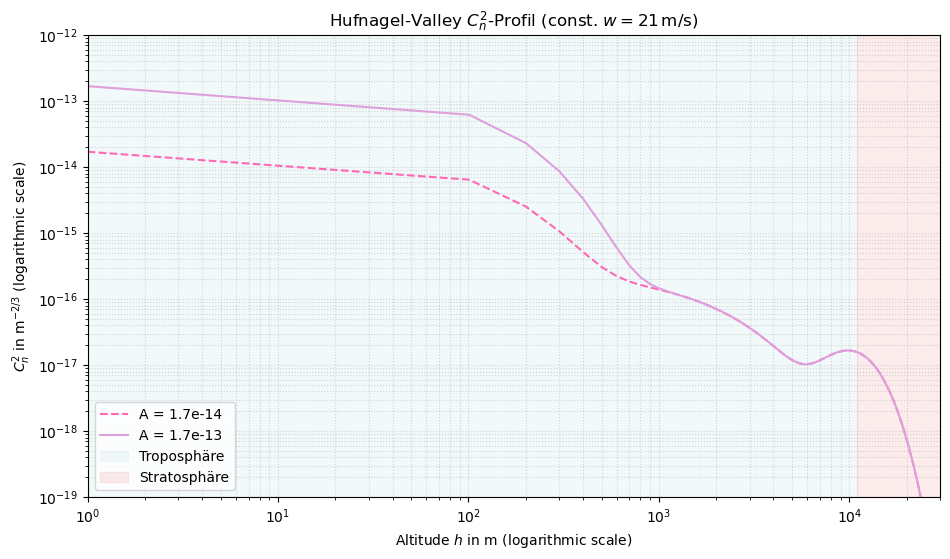

In [6]:
#plot altitude 0-500km leo

w_rms = 21.0 #assumption constant
A_ground_1 = 1.7e-14   # Standard-Normalwert
A_ground_2 = 1.7e-13   # Starker Bodenturbulenz-Wert (z.B. Stadtumgebung)


altitude = np.arange(1, 500001, 100)

cn2_profile_1 = hufnagel_valley_profile(altitude, w_rms, A_ground_1)
cn2_profile_2 = hufnagel_valley_profile(altitude, w_rms, A_ground_2)


# --- DOPPELLOGARITHMISCHER PLOT (LOG-LOG) ---
plt.figure(figsize=(11, 6))


plt.loglog(altitude, cn2_profile_1, label=f"A = {A_ground_1:.1e}", color='hotpink', linestyle='--')
plt.loglog(altitude, cn2_profile_2, label=f"A = {A_ground_2:.1e}", color='plum')


plt.axvspan(1, 11000, color='lightblue', alpha=0.15, label='Troposphäre')
plt.axvspan(11000, 30000, color='lightcoral', alpha=0.15, label='Stratosphäre')


plt.xlabel("Altitude $h$ in m (logarithmic scale)")
plt.ylabel("$C_n^2$ in $\\text{m}^{-2/3}$ (logarithmic scale)")
plt.title("Hufnagel-Valley $C_n^2$-Profil (const. $w=21\\,\\text{m/s}$)")

plt.xlim(1, 30000)
plt.ylim(1e-19, 1e-12)

plt.grid(True, which="both", ls=":", alpha=0.5)
plt.legend(loc="lower left") 
plt.show()



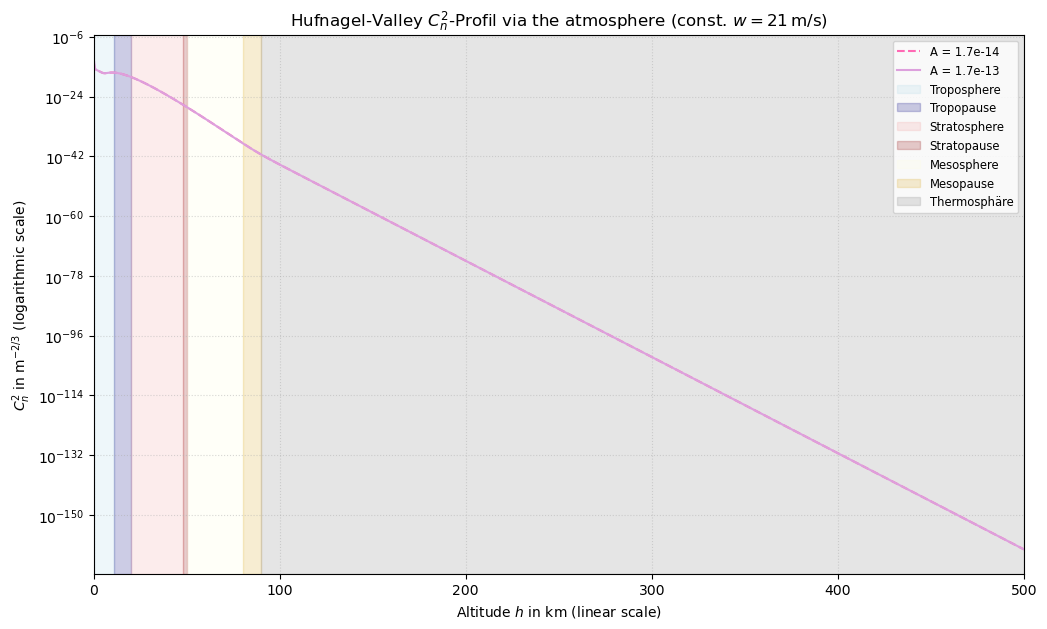

In [7]:
# --- LINEARE HÖHENACHSE BIS 500 KM (SEMILOGY) ---
plt.figure(figsize=(12, 7))

altitude_km = altitude / 1000.0

# semilogy: X-Achse (Höhe) ist linear, Y-Achse (Cn2) ist logarithmisch
plt.semilogy(altitude_km, cn2_profile_1, label=f"A = {A_ground_1:.1e}", color='hotpink', linestyle='--')
plt.semilogy(altitude_km, cn2_profile_2, label=f"A = {A_ground_2:.1e}", color='plum')

# Maßstabsgetreue Zonen bis 500 km LEO-Orbit einzeichnen
plt.axvspan(0, 10999/1000, color='lightblue', alpha=0.2, label='Troposphere')
plt.axvspan(11000/1000,19999/1000, color='navy', alpha=0.2, label='Tropopause')

plt.axvspan(20000/1000, 47999/1000, color='lightcoral', alpha=0.15, label='Stratosphere')
plt.axvspan(48000/1000,49999/1000 , color='darkred', alpha=0.2, label='Stratopause')

plt.axvspan(50000/1000, 79999/1000, color='lightyellow', alpha=0.2, label='Mesosphere')
plt.axvspan(80000/1000, 89999/1000, color='goldenrod', alpha=0.2, label='Mesopause')

plt.axvspan(90000/1000, 500000/1000, color='grey', alpha=0.2, label='Thermosphäre')


# Achsenbeschriftung und Titel
plt.xlabel("Altitude $h$ in km (linear scale)")
plt.ylabel("$C_n^2$ in $\\text{m}^{-2/3}$ (logarithmic scale)")
plt.title("Hufnagel-Valley $C_n^2$-Profil via the atmosphere (const. $w=21\\,\\text{m/s}$)")

# Grenzen anpassen: X-Achse linear bis 500 km, Y-Achse für Cn2-Dynamik
plt.xlim(0, 500000/1000)
#plt.ylim(1e-25, 1e-12)

# Gitternetz und Legende (oben rechts, da die Kurve links kollabiert)
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.legend(loc="upper right", fontsize='small')
plt.show()

In [8]:
# slider for zenith angle
#slider for wavelength
#turbolenz = #CN^2

#BERECHNE FRIEDPARAMETER


def hufnagel_valley_profile(h, w, A): #C_n^2
    """
    A: ground level value of C_n^2(0)
    """
    term1 = 0.00594 * (w / 27.0)**2 * (1e-5 * h)**10 * np.exp(-h / 1000.0)
    term2 = 2.7e-16 * np.exp(-h / 1500.0)
    term3 = A * np.exp(-h / 100.0)
    return term1 + term2 + term3



w_effektiv = calculate_w_rms(0, 2.1, 5000, 20000) 
h = np.linspace(0, 500*1e3, 1000)


integral = quad(lambda h: hufnagel_valley_profile(h, w_effektiv, 1.7e-14), 0, 500000)[0]


def fried_parameter(wavelength, zenith_angle):
    k = (2 * np.pi) / wavelength
    sec_zeta = 1.0 / np.cos(zenith_angle)
    # KORREKTUR: k^2 steht im Zähler des Terms, der mit -3/5 potenziert wird
    return (0.423 * sec_zeta * (k**2) * integral)**(-3/5)
def plot(wavelength, zenith_angle):
    r_0 = fried_parameter(wavelength, zenith_angle)

    z = np.linspace(0.1, 500*1e3, 500)  # Distance from the source in meters

    r_0_array = np.full_like(z, r_0 * 100) # direkt in cm für bessere Lesbarkeit

    plt.figure(figsize=(8,4))
    plt.plot(z,r_0_array,  color='hotpink')

    plt.title("Gaussian Beam")
    plt.ylabel("Friedparamter")
    plt.xlabel("z (m))")
    plt.axvline(1, color='gray', linestyle='--', label= f"z=1m")
    plt.axvline(10, color='steelblue', linestyle='--', label= f"z=10m")
    plt.axvline(100, color='darkgreen', linestyle='--', label= f"z=100m")
    plt.grid(True)
    plt.legend(loc='best')

    #plt.savefig("beam_waist_for_1_10_100m.pdf", format="pdf")
    plt.show()

interact(
    plot,
    wavelength=FloatSlider(
        value=1550e-9,
        min=400e-9,
        max=2000e-9,
        step=50e-9,
        description="Wavelength (m)"), 
    zenith_angle=FloatSlider(
        value=0,
        min=0,
        max=np.pi/2,
        step=np.pi/180,
        description="Zenith Angle (radians)")
)       


interactive(children=(FloatSlider(value=1.55e-06, description='Wavelength (m)', max=2e-06, min=4e-07, step=5e-…

<function __main__.plot(wavelength, zenith_angle)>

In [ ]:
def hufnagel_valley_profile(h, w, A): #C_n^2
    """
    A: ground level value of C_n^2(0)
    """
    term1 = 0.00594 * (w / 27.0)**2 * (1e-5 * h)**10 * np.exp(-h / 1000.0)
    term2 = 2.7e-16 * np.exp(-h / 1500.0)
    term3 = A * np.exp(-h / 100.0)
    return term1 + term2 + term3



w_effektiv = calculate_w_rms(0, 2.1, 5000, 20000) 
h = np.linspace(0, 500*1e3, 1000)


integral = quad(lambda h: hufnagel_valley_profile(h, w_effektiv, 1.7e-14), 0, 500000)[0]

def fried_parameter(wavelength, zenith_angle):
    k = (2 * np.pi) / wavelength
    sec_zeta = 1.0 / np.cos(zenith_angle)
    # KORREKTUR: k^2 steht im Zähler des Terms, der mit -3/5 potenziert wird
    return (0.423 * sec_zeta * (k**2) * integral)**(-3/5)


def plot(wavelength, zenith_angle):
    if zenith_angle >= np.pi/2:
        zenith_angle = np.pi/2 - 1e-4

    k = (2 * np.pi) / wavelength
    sec_zeta = 1.0 / np.cos(zenith_angle)
    
    # Höhen-Array von LEO (500 km) runter zum Boden (0 km)
    z_km = np.linspace(500, 0, 200) 
    r_0_verlauf = []

    # Schleife berechnet kumulierte Turbulenz von oben (500km) bis zur aktuellen Höhe h
    for h_aktuell in z_km:
        if h_aktuell >= 40: 
            # Im tiefen Weltraum (>40km) ist Cn2 praktisch 0, r_0 ist quasi unendlich
            r_0_verlauf.append(999.0) # Platzhalter für "unendlich" im Plot
        else:
            # Strahl kommt von oben (500km) und ist jetzt bei h_aktuell angekommen
            # Integriert wird die bereits durchquerte Luftschicht von 500km runter zu h_aktuell
            integral_teil = quad(lambda h: hufnagel_valley_profile(h, w_effektiv, 1.7e-14), h_aktuell*1000, 500000)[0]
            
            if integral_teil <= 0:
                r_0_verlauf.append(999.0)
            else:
                r_0 = (0.423 * sec_zeta * (k**2) * integral_teil)**(-3/5)
                r_0_verlauf.append(r_0 * 100) # in cm

    plt.figure(figsize=(10, 6))
    plt.plot(r_0_verlauf, z_km, color='hotpink', linewidth=2.5, label="Kumulatives $r_0(h)$")

    plt.title(f"Dynamische Entwicklung des Fried-Parameters beim Eintritt in die Atmosphäre")
    plt.xlabel("Effektiver Fried-Parameter $r_0$ (cm)")
    plt.ylabel("Aktuelle Höhe des Laserstrahls $h$ (km)")
    
    plt.xlim(0, 30) # Fokus auf den interessanten Bereich am Boden
    plt.ylim(0, 80) # Wir zeigen die ersten 80 km, darüber ist alles unendlich
    plt.grid(True, ls=":", alpha=0.6)
    plt.legend()
    plt.show()

def plot_from_nm(wavelength_nm, zenith_angle):
    wavelength = wavelength_nm * 1e-9  # convert nm -> m
    plot(wavelength, zenith_angle)

interact(
    plot_from_nm,
    wavelength_nm=FloatSlider(
        value=1550,
        min=400,
        max=2000,
        step=50,
        description="Wavelength (nm)"
    ),
    zenith_angle=FloatSlider(
        value=0,
        min=0,
        max=np.pi / 2,
        step=np.pi / 180,
        description="Zenith Angle (radians)"
    )
)       


interactive(children=(FloatSlider(value=1550.0, description='Wavelength (nm)', max=2000.0, min=400.0, step=50.…

<function __main__.plot_from_nm(wavelength_nm, zenith_angle)>

In [12]:
# gibt divergenz minimum aus


def theta_min(wavelength_nm, zenith_angle_deg):
    wl_m = wavelength_nm * 1e-9
    zenith_rad = np.radians(zenith_angle_deg) # Umrechnung von Grad in Radiant
    
    r_0 = fried_parameter(wl_m, zenith_rad)
    
    # 3. Minimale Divergenz (Seeing-Limit)
    theta_0_value = wl_m / r_0
    

    print(f"Minimum Divergence: {theta_0_value:.3e} rad  ({theta_0_value * 1e6:.2f} µrad)")
    return theta_0_value


interact(
    theta_min,
    wavelength_nm=FloatSlider(
        value=1064, min=400, max=2000, step=1,
        description="Wavelength (nm)"),
    zenith_angle_deg=FloatSlider(
        value=0, min=0, max=90, step=1,
        description="Zenith Angle (°)")
)




interactive(children=(FloatSlider(value=1064.0, description='Wavelength (nm)', max=2000.0, min=400.0, step=1.0…

<function __main__.theta_min(wavelength_nm, zenith_angle_deg)>